# Agentic RAG project results and visual comparison
Adarsh Konderu — supervisor feedback and demonstration notebook

This notebook explains the completed experiment using the saved evidence: 15 questions, three conditions and 45 reports. It calculates graphs from the report-level and judge-level records, rather than entering summary scores by hand.

**Start here:** Run the cells in order. No GPU, API key or model download is needed. The evidence is included inside this notebook, so no ZIP upload is required. Outputs are research examples, not clinical advice.

This notebook displays my **saved results**; it does not generate new reports. I have kept the original generation notebooks and their inputs in the accompanying package because they require a GPU and take longer to run. My approved ethics form and the other assessment documents are stored separately from this results notebook.


## 1 The three conditions
- **A — Single-pass LLM:** one generated report without retrieval or agent roles.
- **B — Agentic without RAG:** planning, writing and review without retrieved passages.
- **C — Agentic RAG:** planning, hybrid retrieval, evidence review, writing and claim verification.

The generator was Qwen2.5-3B-Instruct. The final cleaned corpus contained 46 articles and 1,415 chunks. Multiple roles do not mean that each role used a different language model.

The main question is whether the extra stages improve report quality enough to justify their cost in time. C adds retrieval and verification together, so this experiment cannot separate their individual effects.


## 2 Load the frozen evidence
The compressed data below is just a portable copy of the saved files. The SHA-256 check detects changes to that copy. It does not prove that the model outputs are factually correct.


In [1]:
import base64, hashlib, io, json, zipfile
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

EVIDENCE_BASE64 = '...'
EXPECTED_SHA256 = '8f6b5f4df1cde57dc6920f893bbd7a37a5018c12ec9e810f58966604d6e4c655'
raw = base64.b64decode(EVIDENCE_BASE64)
assert hashlib.sha256(raw).hexdigest() == EXPECTED_SHA256, 'Evidence checksum mismatch'
# Read the archive in memory; do not extract arbitrary paths.
evidence_zip = zipfile.ZipFile(io.BytesIO(raw))
def read_csv(name):
    return pd.read_csv(io.BytesIO(evidence_zip.read(name)))
metrics = read_csv('automated_metrics.csv')
judges = read_csv('judges/all_judge_scores.csv')
retrieved = read_csv('retrieved_evidence.csv')
claims = read_csv('claim_audit.csv')
cases = [json.loads(line) for line in evidence_zip.read('evaluation_cases.jsonl').decode().splitlines()]
conditions = ['A', 'B', 'C']
judge_order = ['granite', 'mistral', 'phi']
colours = ['#0072B2', '#E69F00', '#009E73']
labels = ['A: Single pass', 'B: Agentic without RAG', 'C: Agentic RAG']
graph_dir = Path('project_graphs')
graph_dir.mkdir(exist_ok=True)
plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})
def finish(fig, filename):
    fig.tight_layout()
    fig.savefig(graph_dir / filename, dpi=180, bbox_inches='tight')
    plt.show()

# Each question must have exactly one report per condition and one rating per judge.
assert len(cases) == 15 and len(metrics) == 45 and len(judges) == 135
assert not metrics.duplicated(['question_id','condition']).any()
assert not judges.duplicated(['judge_id','question_id','condition']).any()
assert set(metrics.condition) == set(conditions)
assert set(judges.judge_id) == set(judge_order)
assert metrics.groupby('condition').size().eq(15).all()
assert judges.groupby(['judge_id','condition']).size().eq(15).all()
assert judges.criterion_mean.between(1,5).all()
for case in cases:
    assert {r['condition'] for r in case['reports']} == set(conditions)
    for report in case['reports']:
        assert hashlib.sha256(report['original_text'].encode()).hexdigest() == report['original_sha256']
print('Validated: 15 questions, 45 unchanged reports and 135 judge ratings.')
print('A = single pass; B = agentic without RAG; C = agentic RAG.')


Matplotlib is building the font cache; this may take a moment.


Validated: 15 questions, 45 unchanged reports and 135 judge ratings.
A = single pass; B = agentic without RAG; C = agentic RAG.


## 3 Compare the three judges
Each bar is the mean of 15 report ratings, each rating averaging the five rubric criteria. The rating scale is **1–5**, not a percentage. Bars show means only; they are not confidence intervals or significance tests.


condition,A,B,C
judge_id,,,
granite,4.867,4.867,4.867
mistral,4.013,4.360,3.587
phi,3.520,3.320,3.453


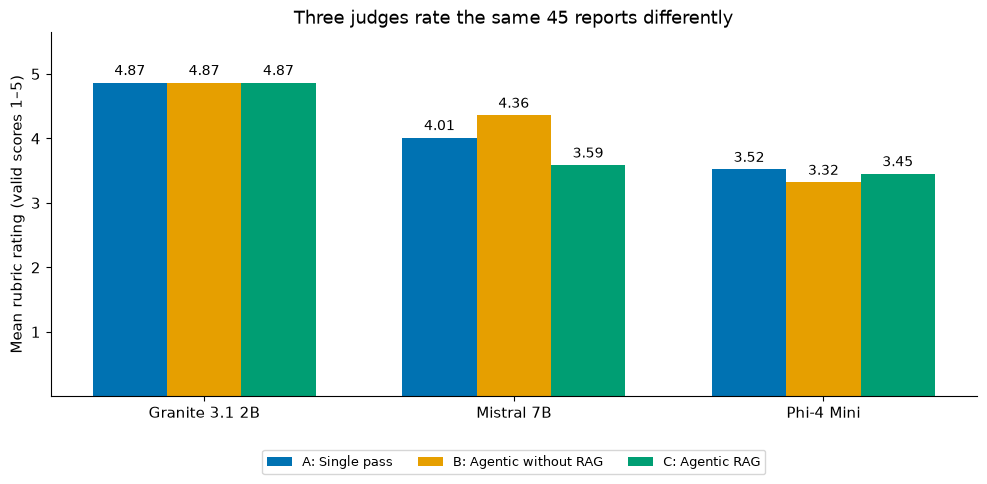

In [2]:
judge_means = judges.groupby(['judge_id','condition']).criterion_mean.mean().unstack().reindex(judge_order)[conditions]
display(judge_means.round(3))
fig, ax = plt.subplots(figsize=(10,5))
x = np.arange(3)
for j, condition in enumerate(conditions):
    bars = ax.bar(x + (j-1)*0.24, judge_means[condition], width=0.24, color=colours[j], label=labels[j])
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=10)
ax.set_xticks(x, ['Granite 3.1 2B','Mistral 7B','Phi-4 Mini'])
ax.set_ylim(0,5.65)
ax.set_yticks([1,2,3,4,5])
ax.set_ylabel('Mean rubric rating (valid scores 1–5)')
ax.set_title('Three judges rate the same 45 reports differently')
ax.legend(loc='upper center', bbox_to_anchor=(0.5,-0.13), ncol=3, fontsize=9)
finish(fig, '01_three_judge_comparison.png')


**What this shows:** Granite gives almost identical high means across the conditions, while Mistral and Phi have different preferences. Granite's ceiling effect and disagreement between judges limit confidence in any one judge.

**What we cannot conclude:** These ratings do not prove factual accuracy or establish that C is the best workflow. The judges are models, not human participants.


## 4 Compare generation time
These are the saved run times, not a new hardware benchmark. Each dot is one report, and bars show the mean of 15 reports. Fixed A → B → C execution order and the shared runtime can influence timing.


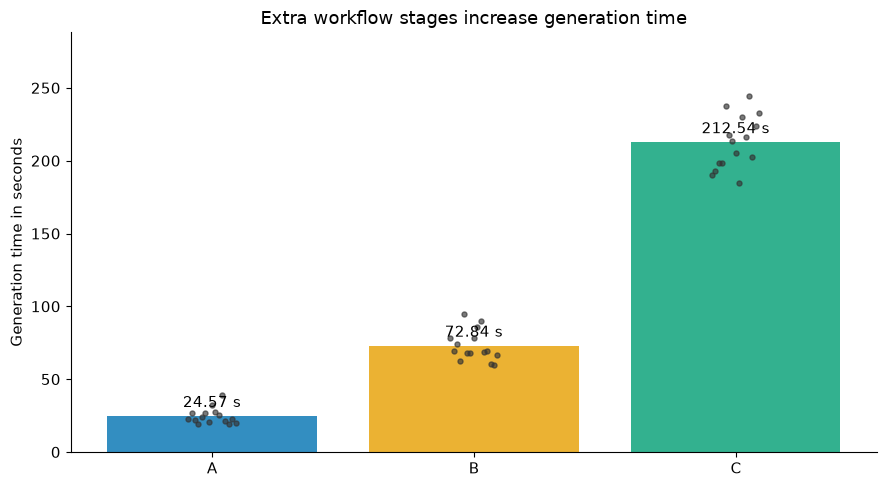

C/A mean time ratio: 8.65 times


In [3]:
fig, ax = plt.subplots(figsize=(9,5))
means = metrics.groupby('condition').generation_seconds.mean().reindex(conditions)
bars = ax.bar(conditions, means, color=colours, alpha=0.8)
for i,c in enumerate(conditions):
    values = metrics.loc[metrics.condition.eq(c),'generation_seconds'].to_numpy()
    ax.scatter(i+np.linspace(-0.09,0.09,len(values)), values, color='#333333', s=13, alpha=0.65)
ax.bar_label(bars, fmt='%.2f s', padding=4)
ax.set_ylim(0, metrics.generation_seconds.max()*1.18)
ax.set_ylabel('Generation time in seconds')
ax.set_title('Extra workflow stages increase generation time')
finish(fig, '02_generation_time.png')
print(f'C/A mean time ratio: {means["C"]/means["A"]:.2f} times')


**My interpretation:** C is slower because it performs additional work. More processing time is worthwhile only if its benefits are useful for the intended task; slower does not automatically mean better.


## 5 Check report structure
The structure check asks whether the report follows the required sections. It is not a test of factual correctness.


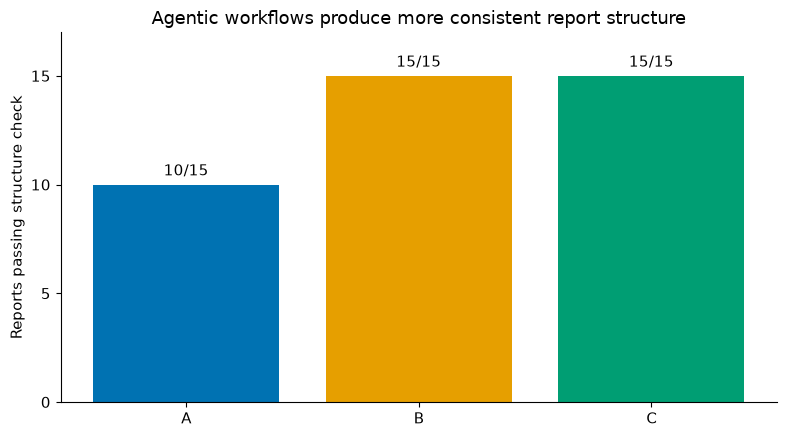

In [4]:
passed = metrics.structure_passed.astype(str).str.lower().eq('true')
structure = metrics.assign(passed=passed).groupby('condition').passed.sum().reindex(conditions)
fig, ax = plt.subplots(figsize=(8,4.5))
bars = ax.bar(conditions, structure, color=colours)
ax.bar_label(bars, labels=[f'{int(v)}/15' for v in structure], padding=4)
ax.set_ylim(0,17); ax.set_yticks([0,5,10,15])
ax.set_ylabel('Reports passing structure check')
ax.set_title('Agentic workflows produce more consistent report structure')
finish(fig, '03_structure_checks.png')


## 6 Compare automated measures
Each panel uses a different embedding-based measure. Similarity is not accuracy, and these values are **not ratings out of five**. All panels show means across 15 reports per condition. The full cosine scale is retained.


,question_relevance_cosine,evidence_support_mean,evidence_coverage_mean
condition,,,
A,0.740,0.506,0.640
B,0.709,0.481,0.643
C,0.616,0.504,0.659


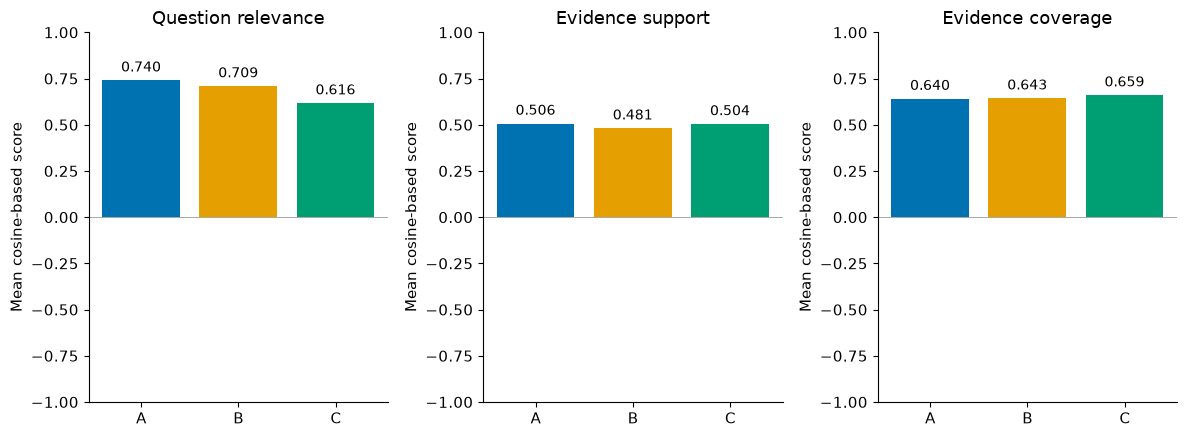

In [5]:
columns = ['question_relevance_cosine','evidence_support_mean','evidence_coverage_mean']
titles = ['Question relevance','Evidence support','Evidence coverage']
summary = metrics.groupby('condition')[columns].mean().reindex(conditions)
display(summary.round(3))
fig, axes = plt.subplots(1,3,figsize=(12,4.5))
for ax,column,title in zip(axes,columns,titles):
    bars = ax.bar(conditions, summary[column], color=colours)
    ax.bar_label(bars,fmt='%.3f',padding=4,fontsize=10)
    ax.set_ylim(-1,1); ax.axhline(0,color='#999999',linewidth=0.6)
    ax.set_title(title); ax.set_ylabel('Mean cosine-based score')
finish(fig, '04_automated_measures.png')


**My interpretation:** C has slightly higher evidence coverage but lower question relevance. These are trade-offs, not evidence of an overall win. Coverage was not significantly different in the saved test (p ≈ .627). Evidence support and claim-verifier support are different measures and should not be mixed.


## 7 Read a saved example and inspect its evidence
Change `QUESTION_ID` to any ID printed below and rerun the next cell. This displays the original frozen reports, retrieved passages and claim checks. It does not generate a new answer or perform a new search. Retrieved passages and judge explanations may themselves contain errors.


In [6]:
print('Available questions:', ', '.join(c['question_id'] for c in cases))
QUESTION_ID = 'M1'
case = next((c for c in cases if c['question_id'] == QUESTION_ID), None)
assert case is not None, 'Choose an ID from the printed list'
display(Markdown('### Question\n' + case['question']))
for report in sorted(case['reports'],key=lambda r:r['condition']):
    display(Markdown('### Saved condition ' + report['condition']))
    display(Markdown(report['original_text']))
display(Markdown('### Retrieved evidence used for condition C'))
display(retrieved.loc[retrieved.question_id.eq(QUESTION_ID), ['chunk_id','pmcid','title','source_url','text']])
display(Markdown('### Sentence-level claim checks for condition C'))
display(claims.loc[claims.question_id.eq(QUESTION_ID), ['claim','status','best_pmcid','best_evidence_window','entailment_probability']])
display(Markdown('### Judge scores and reasons for this question'))
display(judges.loc[judges.question_id.eq(QUESTION_ID), ['judge_id','condition','criterion_mean','brief_reason']])


Available questions: M1, M2, M3, C1, C2, C3, O1, O2, O3, G1, G2, G3, E1, E2, E3


### Question
How can AI-assisted ultrasound support diagnosis, and what technical and clinical barriers must be addressed before routine use?

### Saved condition A

# Introduction
The integration of artificial intelligence (AI) into ultrasound imaging has the potential to revolutionize diagnostic accuracy and efficiency. By leveraging machine learning algorithms, AI can analyze ultrasound images in real-time, aiding radiologists in identifying subtle abnormalities and distinguishing between benign and malignant conditions. However, this technology is still in its developmental stages, facing significant technical and clinical challenges.

## Benefits of AI-Assisted Ultrasound
One of the primary benefits of AI-assisted ultrasound is enhanced diagnostic precision. Machine learning models can detect patterns and anomalies that may be missed by human observers, leading to more accurate diagnoses. Additionally, AI can provide immediate feedback during the examination, allowing for quicker identification and treatment of conditions. Furthermore, AI can assist in the early detection of diseases, such as cancer, which can lead to better patient outcomes.

## Limitations and Challenges
Despite these advantages, there are several technical and clinical barriers that must be overcome before AI-assisted ultrasound becomes a standard tool in clinical practice. One major challenge is ensuring the reliability and consistency of AI-generated results. The performance of AI systems can vary depending on the quality and quantity of training data, and the system's ability to adapt to different imaging modalities and patient populations needs further investigation. Clinically, there is also a need to address concerns about privacy and security, as AI systems process large amounts of sensitive medical information. Moreover, there is a risk of overreliance on AI, potentially leading to complacency among healthcare professionals.

## Conclusion
In summary, AI-assisted ultrasound holds great promise for improving diagnostic accuracy and enhancing patient care. However, it is essential to address the technical and clinical challenges associated with its implementation. Ongoing research and development will be crucial in refining AI algorithms and addressing the ethical and practical issues surrounding their use. As these hurdles are overcome, AI-assisted ultrasound could become an invaluable tool in the field of diagnostic imaging.

### Saved condition B

...

,chunk_id,pmcid,title,source_url,text
0,PMC12418068_C0011,PMC12418068,"AI Revolution in Radiology, Radiation Oncology...",https://pmc.ncbi.nlm.nih.gov/articles/PMC12418...,"transformative role in radiology. To date, a t..."
1,PMC12933003_C0032,PMC12933003,Artificial Intelligence in Healthcare: From Di...,https://pmc.ncbi.nlm.nih.gov/articles/PMC12933...,studies indicate that AI-assisted double-readi...
2,PMC12492054_C0008,PMC12492054,The Evolving Role of Artificial Intelligence i...,https://pmc.ncbi.nlm.nih.gov/articles/PMC12492...,"specific diagnostics, clinical decision making..."
3,PMC12933003_C0034,PMC12933003,Artificial Intelligence in Healthcare: From Di...,https://pmc.ncbi.nlm.nih.gov/articles/PMC12933...,"adaptability, and patient safety persist [ 27 ..."
4,PMC12933003_C0013,PMC12933003,Artificial Intelligence in Healthcare: From Di...,https://pmc.ncbi.nlm.nih.gov/articles/PMC12933...,"5 , 6 ]. These approaches have demonstrated po..."
5,PMC11939760_C0003,PMC11939760,Progress in the Application of Artificial Inte...,https://pmc.ncbi.nlm.nih.gov/articles/PMC11939...,"as a non-invasive, convenient, and cost-effect..."


### Sentence-level claim checks for condition C

,claim,status,best_pmcid,best_evidence_window,entailment_probability
0,AI-based software applications have received C...,unsupported,PMC12418068,The latest comprehensive list of these approve...,0.0026
1,Neuroradiology has seen significant advancemen...,supported,PMC12418068,"Of these, detection applications were the firs...",0.9958
2,AI-assisted double-reading strategies have imp...,supported,PMC12933003,"In ophthalmology, AI-enabled screening for dia...",0.9965
3,"In radiology and digital pathology, AI support...",supported,PMC12933003,"In radiology and digital pathology, AI systems...",0.9968
4,Studies selected for analysis covered various ...,supported,PMC12492054,Characteristics of Selected Studies Twelve stu...,0.9974
5,"They used data from EHRs, imaging datasets, cl...",supported,PMC12492054,Those studies used data from electronic health...,0.9937
6,"However, they also highlighted challenges such...",supported,PMC12492054,The studies were global in geographical scope;...,0.9985
7,Adaptive AI systems in imaging have shown high...,unsupported,PMC12933003,While these studies consistently demonstrate h...,0.0838
8,Only certain applications in rehabilitation an...,supported,PMC12933003,"In contrast, selected applications in rehabili...",0.9976
9,Clinical benefit requires more than just accur...,unsupported,PMC12933003,"Importantly, technical performance alone does ...",0.3956


### Judge scores and reasons for this question

,judge_id,condition,criterion_mean,brief_reason
0,granite,A,5.0,This report comprehensively addresses the rese...
1,granite,B,5.0,This report thoroughly addresses the research ...
2,granite,C,5.0,This report effectively addresses the research...
45,mistral,B,5.0,The report provides a comprehensive analysis o...
46,mistral,C,3.0,The report discusses various AI applications i...
47,mistral,A,5.0,The report provides a clear and concise discus...
90,phi,A,3.0,Report 1 provides a comprehensive overview of ...
91,phi,C,2.0,Report 2 touches on the benefits and challenge...
92,phi,B,1.0,Report 3 fails to adequately address the resea...


## 8 Overall interpretation and limitations
The prototype demonstrates structured generation, traceable evidence and automated checks. It does not demonstrate that Agentic RAG is universally better.

- Only 15 questions, one generator and one healthcare literature corpus were tested.
- The saved question-level comparison of pooled judge scores was not statistically significant (p ≈ .109).
- Absolute inter-judge agreement was low (ICC(2,1) ≈ .058). Three models do not replace independent human evaluation.
- Condition C combines retrieval with verification, so their separate contributions are unknown.
- Ten Phi outputs needed documented extraction of the leading valid JSON object; the scores were not changed.
- Human evaluation has not been conducted. Confirm the assessment requirement and any necessary ethics amendment with the supervisor before recruiting anyone.

The AI models evaluated in this study are separate from the AI tools I used to support my own work. I used AI support for brainstorming, code organisation, debugging and clearer explanations. I checked the notebook and I remain responsible for understanding the code, explaining the method and reporting the assistance accurately in my assessment declaration.


## 9 Export graphs and the underlying data
This creates a ZIP of the four graph PNGs and CSV records. In Colab, expand the Files panel to download it. Set `DOWNLOAD_RESULTS = True` to request a browser download. The default avoids repeated downloads during Run all.


In [7]:
result_path = Path('Adarsh_Konderu_Results_Graphs.zip')
with zipfile.ZipFile(result_path,'w',zipfile.ZIP_DEFLATED) as output:
    for path in sorted(graph_dir.glob('*.png')): output.write(path, 'graphs/'+path.name)
    for name in ['automated_metrics.csv','judges/all_judge_scores.csv']:
        output.writestr('data/'+name, evidence_zip.read(name))
    output.writestr('data/judge_means.csv',judge_means.to_csv())
    output.writestr('data/automated_means.csv',summary.to_csv())
print('Saved:', result_path.resolve())
DOWNLOAD_RESULTS = False
if DOWNLOAD_RESULTS:
    from google.colab import files
    files.download(str(result_path))
